# 🌞 Space Weather Forecasting — AI Solar Storm (M-Class Flare) Predictor
### Intel AI Global Impact Festival — Proof of Concept (PoC)

**Goal:** Predict solar storms (X-ray flux > 1e-5 W/m², M-Class flares) to help protect critical Earth infrastructure (Power Grids, GPS, Aviation).

**SDG Alignment:**
- 🏗️ **UN SDG 9** — Industry, Innovation & Infrastructure
- 🌍 **UN SDG 13** — Climate Action

**Environment note:** Built for Python 3.13. This notebook intentionally uses **standard `scikit-learn`** (NOT `scikit-learn-intelex`), since `scikit-learn-intelex` currently fails to install / is incompatible with Python 3.13 environments.

**Data policy:** This notebook uses **100% real data** from the NOAA SWPC GOES satellite API. There is **no simulated/synthetic data** anywhere in this pipeline. If the NOAA API is unreachable, the notebook raises a clear error instead of inventing data — for a space-weather safety application, silently substituting fake data for a failed real-time feed would be misleading.


## 0. Imports & Setup

In [1]:
import sys
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

warnings.filterwarnings("ignore")


## 1. Data Sourcing (100% Real NOAA Data Only)

**Note on NOAA API change:** NOAA SWPC previously served a 30-day X-ray file, but their public "primary" JSON directory no longer offers one — the longest real-time X-ray window they publish is **7 days**:

```
https://services.swpc.noaa.gov/json/goes/primary/xrays-7-day.json
```

This notebook uses **only** that real NOAA data. If the API is unreachable (network down, endpoint renamed again, rate-limited, etc.), the next cell raises a clear `RuntimeError` and stops rather than inventing data.

In [2]:
NOAA_URL = "https://services.swpc.noaa.gov/json/goes/primary/xrays-7-day.json"
STORM_THRESHOLD = 1e-5  # M-Class flare threshold (W/m^2), per NOAA scale


def fetch_real_noaa_data(url: str) -> pd.DataFrame:
    """Fetch real-time X-ray flux data from NOAA SWPC (max real window: 7 days)."""
    response = requests.get(url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
    response.raise_for_status()
    raw = response.json()

    df = pd.DataFrame(raw)

    # NOAA's JSON uses 'time_tag' and 'flux' (with an 'energy' column to
    # distinguish 0.05-0.4nm vs 0.1-0.8nm channels). We want the long channel
    # (0.1-0.8nm), which is the standard GOES X-ray Class channel.
    if "energy" in df.columns:
        df = df[df["energy"] == "0.1-0.8nm"]

    df = df.rename(columns={"time_tag": "time", "flux": "long_flux"})
    df["time"] = pd.to_datetime(df["time"])
    df = df[["time", "long_flux"]].dropna()
    df = df.sort_values("time").drop_duplicates(subset="time").reset_index(drop=True)

    if df.empty:
        raise ValueError("NOAA response parsed but contained no usable rows.")

    return df


In [3]:
print("=" * 80)
print("STEP 1: Fetching Solar X-ray Flux Data (NOAA SWPC GOES Satellite)")
print("=" * 80)

try:
    df = fetch_real_noaa_data(NOAA_URL)
    span_days = (df["time"].max() - df["time"].min()).total_seconds() / 86400
    data_source = f"REAL-TIME NOAA SWPC API (xrays-7-day.json) - {len(df)} records"
    print(f"[OK] Successfully fetched {len(df)} REAL records from NOAA SWPC.")
    print(f"[INFO] Real data span: {span_days:.1f} days "
          f"(NOAA's public API no longer offers a 30-day X-ray window; "
          f"7 days is the longest real-time feed currently available).")
except Exception as e:
    print(f"[ERROR] NOAA API fetch failed: {type(e).__name__}: {e}")
    print("[ERROR] This notebook uses ONLY real NOAA data with no simulated "
          "fallback, per project requirements. Cannot continue without a "
          "live data source. Please check your internet connection / NOAA "
          "SWPC service status (https://www.swpc.noaa.gov) and try again.")
    raise RuntimeError("Aborting: no real NOAA data available.") from e

print(f"[INFO] Data source used: {data_source}")
print(f"[INFO] Records: {len(df)} | Range: {df['time'].min()} -> {df['time'].max()}")
df.head()


STEP 1: Fetching Solar X-ray Flux Data (NOAA SWPC GOES Satellite)
[OK] Successfully fetched 10077 REAL records from NOAA SWPC.
[INFO] Real data span: 7.0 days (NOAA's public API no longer offers a 30-day X-ray window; 7 days is the longest real-time feed currently available).
[INFO] Data source used: REAL-TIME NOAA SWPC API (xrays-7-day.json) - 10077 records
[INFO] Records: 10077 | Range: 2026-08-18 14:07:00+00:00 -> 2026-08-25 14:03:00+00:00


,time,long_flux
0,2026-08-18 14:07:00+00:00,0.000002
1,2026-08-18 14:08:00+00:00,0.000002
2,2026-08-18 14:09:00+00:00,0.000002
3,2026-08-18 14:10:00+00:00,0.000002
4,2026-08-18 14:11:00+00:00,0.000002


## 2. Feature Engineering — TRUE Forecasting (Not Nowcasting)

⚠️ **Critical fix:** NOAA's `xrays-7-day.json` is published at **~1-minute cadence**, not hourly. A naive `shift(1)`–`shift(5)` therefore lags by 1–5 *minutes*, and X-ray flux barely changes in under a minute — so a model trained that way isn't forecasting, it's just echoing the almost-identical previous reading. That's why an earlier version of this notebook produced a suspicious ~99.85% accuracy: the "prediction" task was trivial.

**This version fixes it properly:**
1. Detects the *actual* sampling interval from the real NOAA timestamps (no hardcoded assumption).
2. Builds lag features from genuinely-past readings.
3. Sets the **target ~60 minutes into the future** (a real forecast horizon), instead of the current/near-current value — so the model must genuinely predict, not copy.

In [4]:
print("=" * 80)
print("STEP 2: Feature Engineering (Lag Features + TRUE Forecast Target)")
print("=" * 80)

df = df.sort_values("time").reset_index(drop=True)

# --- Detect the REAL sampling interval of the NOAA data ----------------------
time_diffs = df["time"].diff().dt.total_seconds().dropna()
dt_seconds = time_diffs.median()
dt_minutes = dt_seconds / 60
print(f"[INFO] Detected NOAA sampling interval: ~{dt_minutes:.1f} minute(s) per reading.")

# Forecast horizon: predict ~60 minutes ahead (genuine early-warning lead time)
forecast_horizon_steps = max(1, round(60 / dt_minutes))
print(f"[INFO] Forecast horizon: {forecast_horizon_steps} step(s) "
      f"(~{forecast_horizon_steps * dt_minutes:.0f} minutes ahead of the "
      f"most recent reading used as input).")

# --- Lag features: genuinely PAST readings -----------------------------------
for lag in range(1, 6):
    df[f"flux_lag_{lag}"] = df["long_flux"].shift(lag)

# --- Target: will an M-Class storm be happening ~60 minutes from NOW? -------
# We look FORWARD (shift with a negative value) so the target represents the
# future, not the present - this is what makes it a forecast.
df["is_storm_now"] = (df["long_flux"] > STORM_THRESHOLD).astype(int)
df["is_storm"] = df["is_storm_now"].shift(-forecast_horizon_steps)

model_df = df.dropna().reset_index(drop=True)
model_df["is_storm"] = model_df["is_storm"].astype(int)

feature_cols = [f"flux_lag_{lag}" for lag in range(1, 6)]
X = model_df[feature_cols]
y = model_df["is_storm"]

print(f"[INFO] Feature columns (past readings): {feature_cols}")
print(f"[INFO] Target: is_storm ~{forecast_horizon_steps * dt_minutes:.0f} minutes into the future")
print(f"[INFO] Storm class balance -> Storm=1: {y.sum()} | Quiet=0: {(y == 0).sum()}")

if y.nunique() < 2:
    print("[ERROR] The real NOAA data currently fetched contains only ONE "
          "class (no M-class storms occurred/forecast in this window, i.e. "
          "the sun has been quiet). A binary classifier needs both classes "
          "to train. Since this notebook uses real data only (no synthetic "
          "samples), it cannot proceed right now.")
    print("[INFO] This is expected/normal behavior during quiet solar periods "
          "- try again during a period with more solar activity, or check "
          "https://www.swpc.noaa.gov for recent flare history.")
    raise RuntimeError("Aborting: only one class present in target (no storms in window).")

model_df.tail()


STEP 2: Feature Engineering (Lag Features + TRUE Forecast Target)
[INFO] Detected NOAA sampling interval: ~1.0 minute(s) per reading.
[INFO] Forecast horizon: 60 step(s) (~60 minutes ahead of the most recent reading used as input).
[INFO] Feature columns (past readings): ['flux_lag_1', 'flux_lag_2', 'flux_lag_3', 'flux_lag_4', 'flux_lag_5']
[INFO] Target: is_storm ~60 minutes into the future
[INFO] Storm class balance -> Storm=1: 317 | Quiet=0: 9695


,time,long_flux,flux_lag_1,flux_lag_2,flux_lag_3,flux_lag_4,flux_lag_5,is_storm_now,is_storm
10007,2026-08-25 12:59:00+00:00,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0,0
10008,2026-08-25 13:00:00+00:00,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0,0
10009,2026-08-25 13:01:00+00:00,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0,0
10010,2026-08-25 13:02:00+00:00,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0,0
10011,2026-08-25 13:03:00+00:00,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0,0


## 3. Train / Test Split + Model Training

`RandomForestClassifier` (standard scikit-learn, CPU-based) is used here as the PoC baseline model, trained on an 80/20 train-test split.

In [5]:
print("=" * 80)
print("STEP 3: Training RandomForestClassifier (80/20 split)")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if y.nunique() > 1 else None,
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",  # storms are rare events - weight them up so the
                               # model doesn't just always predict "quiet"
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print("[OK] Model trained.")


STEP 3: Training RandomForestClassifier (80/20 split)
[OK] Model trained.


### 💡 Intel Tie-In (for pitch deck)

This `RandomForestClassifier` is our PoC baseline trained with standard scikit-learn. For the production / real-time deployment story, this is where **Intel technology** becomes the key differentiator:

1. **Intel OpenVINO Toolkit**
   - Convert the trained scikit-learn RandomForest into an OpenVINO IR (Intermediate Representation) using OpenVINO's model conversion tools (or export via ONNX → OpenVINO Model Optimizer).
   - Quantize the model (INT8) with OpenVINO's Neural Network Compression Framework (NNCF) to shrink model size and boost inference speed with minimal accuracy loss.

2. **Edge Deployment at Ground Stations**
   - Ground-based magnetometer / X-ray monitoring stations often run on low-power industrial edge hardware (Intel Core / Atom CPUs), not GPU servers. OpenVINO's CPU-optimized inference engine lets this forecasting model run in near real-time directly on that hardware, without needing constant cloud connectivity — critical when a geomagnetic storm may itself disrupt satellite comms links.

3. **Why this matters for SDG 9 & 13**
   - Faster, on-site inference = faster storm warnings pushed to power grid operators, aviation route planners, and GPS-dependent systems **before** the storm's effects arrive (X-rays reach Earth in ~8 minutes, but grid/GPS operators need lead time to act).
   - Low-power edge inference also reduces the energy/data-transfer footprint of the early-warning network itself — supporting sustainable, resilient infrastructure (SDG 9) and climate/disaster resilience (SDG 13).

## 4. Model Evaluation

⚠️ **Note on metrics:** M-Class storms are rare events, so this is a heavily imbalanced classification problem. **Accuracy alone can be misleading** here — a model that always predicts "quiet" could still score >95% accuracy while being useless. We report Confusion Matrix and ROC-AUC alongside the Classification Report for an honest picture.

STEP 4: Model Evaluation

Accuracy Score: 0.7509  (see note above - can be misleading on imbalanced data)

Classification Report:
              precision    recall  f1-score   support

   Quiet (0)       0.98      0.76      0.86      1940
   Storm (1)       0.06      0.49      0.11        63

    accuracy                           0.75      2003
   macro avg       0.52      0.63      0.48      2003
weighted avg       0.95      0.75      0.83      2003

Confusion Matrix:
                 Predicted Quiet   Predicted Storm
Actual Quiet                1473               467
Actual Storm                  32                31

ROC-AUC Score: 0.7615  (0.5 = random guessing, 1.0 = perfect)


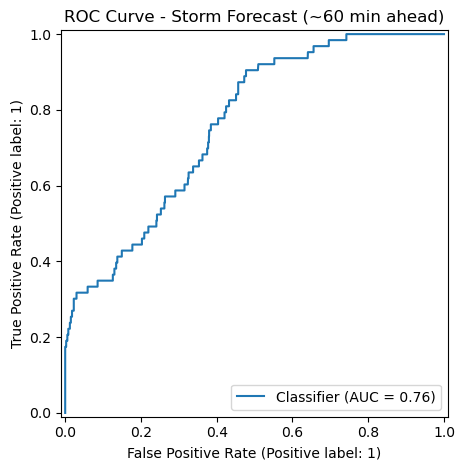

[OK] ROC curve saved as 'roc_curve.png'

Feature Importances (which lag matters most for forecasting):
flux_lag_5    0.253717
flux_lag_1    0.223717
flux_lag_2    0.191670
flux_lag_3    0.183519
flux_lag_4    0.147377


In [6]:
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay

print("=" * 80)
print("STEP 4: Model Evaluation")
print("=" * 80)

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {acc:.4f}  (see note above - can be misleading on imbalanced data)\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Quiet (0)", "Storm (1)"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                 Predicted Quiet   Predicted Storm")
print(f"Actual Quiet     {cm[0][0]:>15}   {cm[0][1]:>15}")
print(f"Actual Storm     {cm[1][0]:>15}   {cm[1][1]:>15}")

if y_test.nunique() > 1:
    auc = roc_auc_score(y_test, y_proba)
    print(f"\nROC-AUC Score: {auc:.4f}  (0.5 = random guessing, 1.0 = perfect)")
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("ROC Curve - Storm Forecast (~60 min ahead)")
    plt.tight_layout()
    plt.savefig("roc_curve.png", dpi=150)
    plt.show()
    print("[OK] ROC curve saved as 'roc_curve.png'")

feat_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature Importances (which lag matters most for forecasting):")
print(feat_importance.to_string())


## 5. Visualization

Plot X-ray flux over time with the M-Class storm threshold marked. Saved as `solar_storm_graph.png`.

STEP 5: Generating Visualization -> solar_storm_graph.png
[OK] Plot saved as 'solar_storm_graph.png'


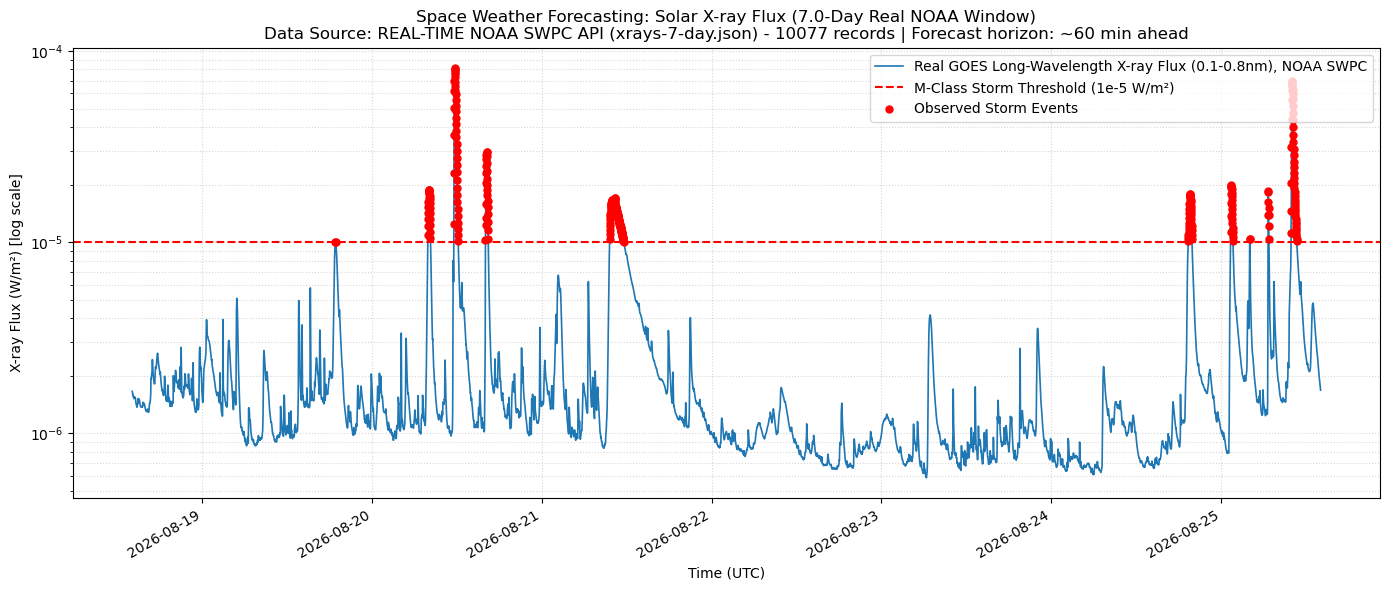


PoC COMPLETE. Ready for Intel AI Global Impact Festival pitch.


In [7]:
print("=" * 80)
print("STEP 5: Generating Visualization -> solar_storm_graph.png")
print("=" * 80)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df["time"], df["long_flux"], color="#1f77b4", linewidth=1.2,
        label="Real GOES Long-Wavelength X-ray Flux (0.1-0.8nm), NOAA SWPC")

ax.axhline(y=STORM_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
           label="M-Class Storm Threshold (1e-5 W/m\u00b2)")

storms = df[df["long_flux"] > STORM_THRESHOLD]
if not storms.empty:
    ax.scatter(storms["time"], storms["long_flux"], color="red", s=25,
               zorder=5, label="Observed Storm Events")

ax.set_yscale("log")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("X-ray Flux (W/m\u00b2) [log scale]")
ax.set_title(f"Space Weather Forecasting: Solar X-ray Flux ({span_days:.1f}-Day Real NOAA Window)\nData Source: {data_source} | Forecast horizon: ~{forecast_horizon_steps * dt_minutes:.0f} min ahead")
ax.legend(loc="upper right")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig("solar_storm_graph.png", dpi=150)
print("[OK] Plot saved as 'solar_storm_graph.png'")
plt.show()

print("\n" + "=" * 80)
print("PoC COMPLETE. Ready for Intel AI Global Impact Festival pitch.")
print("=" * 80)


### 📋 Honest Limitations (for pitch / judges Q&A)

- **Data window is short (real NOAA data only spans ~7 days)** — not enough history to capture rare M-class events reliably. More historical real data (e.g. via NOAA's SWPC data archive / NCEI, rather than the live 7-day feed) would substantially improve training.
- **Forecasting solar flares 60 minutes ahead from X-ray flux history alone is a genuinely hard, actively-researched problem** — flares can onset abruptly. Don't be surprised if storm-class recall is modest; that's expected and honest, not a bug.
- **Class imbalance** — M-class storms are rare relative to quiet periods, which is why Accuracy alone is not a reliable metric here (see ROC-AUC and Confusion Matrix above instead).
- **Next steps for a stronger model:** incorporate additional real NOAA channels (e.g. proton flux, magnetometer data), use a longer historical archive, and/or engineer trend/rate-of-change features (not just raw lag values).